# Data Cleaning Assignment


In [3]:
import pandas as pd

df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [9]:
# Q1. Missing Data Identification

# Scenario: The hospital suspects incomplete patient records.

# Task:
# - Identify missing values in each column
# - Calculate percentage of missing data


# Ans :

df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')

missing_values = df.isnull().sum()
print("\n Missing Values","\n",missing_values)

missing_percentage = (missing_values / len(df)) * 100
print("\n Missing percentage","\n",missing_percentage)


 Missing Values 
 Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64

 Missing percentage 
 Patient_ID             0.000000
Age                   11.764706
Gender                 0.000000
City                   0.000000
Diagnosis              0.000000
Hospital_Visits        0.000000
Treatment_Cost        11.627451
Insurance_Coverage     0.000000
Admission_Date         0.000000
dtype: float64


In [23]:
# Q2. Handling Missing Age

# Scenario : Age is critical for medical analysis, but some values are missing.

# Task:
# - Replace missing Age values with an appropriate method
# - Justify your choice (mean/median)

df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')

print("Missing Age values:", df['Age'].isnull().sum())

print(df['Age'].describe())

median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

print("Missing Age values:", df['Age'].isnull().sum())


Missing Age values: 600
count    4500.000000
mean       49.597556
std        28.663852
min         0.000000
25%        25.000000
50%        50.000000
75%        74.000000
max        99.000000
Name: Age, dtype: float64
Missing Age values: 0


/tmp/ipykernel_3695/4260690621.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


Median is used instead of mean because:
- Age may contain outliers (e.g., very high values like 100+)
- Mean gets affected by outliers
- Median represents the central tendency more accurately

In [35]:
# Q3. Handling Missing Treatment Cost

# Scenario : Treatment cost is highly skewed due to expensive treatments.

# Task:
# Handle missing Treatment_Cost values
# Choose the correct imputation method and explain why


# Ans :

df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')

print("Missing Treatment_Cost values:", df['Treatment_Cost'].isnull().sum())

Avg_diagnosis_cost = df.groupby('Diagnosis')['Treatment_Cost'].median()
print('\n', Avg_diagnosis_cost)

df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Diagnosis'].map(Avg_diagnosis_cost))

print("\nMissing after fill:", df['Treatment_Cost'].isnull().sum())

df.head(10)


Missing Treatment_Cost values: 593

 Diagnosis
Asthma          23919.0
COVID-19        24613.5
Diabetes        24503.5
Flu             26311.0
Hypertension    24513.5
Name: Treatment_Cost, dtype: float64

Missing after fill: 0


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20
5,16265,99.0,Male,Mumbai,Hypertension,5,11948.0,1,2023-09-27
6,10466,55.0,Male,Chennai,Hypertension,7,31710.0,0,2023-08-07
7,14426,88.0,Male,Hyderabad,Flu,13,25910.0,0,2023-05-16
8,15578,NaN,Female,Mumbai,COVID-19,13,24613.5,0,2023-02-04
9,18322,32.0,Female,Delhi,Flu,6,3264.0,1,2023-05-26


Median imputation is used instead of mean because treatment cost data is highly skewed and median is more robust to outliers.
- Handles skewed data
- Not affected by extreme treatment costs
- Gives more realistic values





In [37]:
# Q4. Duplicate Patient Records

# Scenario : Some patient records were entered multiple times.

# Task:
# - Identify duplicate rows
# - Remove duplicates
# - Compare dataset size before and after

# Ans :

df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')

print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows: 99
Duplicate rows after removal: 0


In [46]:
# Q5. Invalid Age Values (Data Quality Check)

# Scenario : Some patients have unrealistic age values (e.g., >100 or <0).

# Task:
# - Detect such records
# - Decide whether to remove or correct them


# Ans :

df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')

Unrealistic_age = df[(df['Age'] > 100) | (df['Age'] < 0) | (df['Age'].isnull())]
print("Invalid Age Records:\n", Unrealistic_age)
print("\nNumber of invalid records:", len(Unrealistic_age))

df = df[(df['Age'] >= 0) & (df['Age'] <= 100) & (~df['Age'].isnull())]

print("\nDataset shape after removing invalid ages:", df.shape)


Invalid Age Records:
       Patient_ID  Age  Gender       City     Diagnosis  Hospital_Visits  \
8          15578  NaN  Female     Mumbai      COVID-19               13   
12         16949  NaN    Male     Mumbai      Diabetes                9   
23         12558  NaN    Male    Chennai           Flu                9   
26         12747  NaN  Female      Delhi        Asthma               15   
29         10189  NaN    Male      Delhi      Diabetes                8   
...          ...  ...     ...        ...           ...              ...   
5095       11764  NaN  Female     Mumbai      COVID-19               15   
5096       17597  NaN  Female    Chennai        Asthma                2   
5097       19171  NaN  Female     Mumbai           Flu                1   
5098       13854  NaN  Female  Bangalore           Flu               17   
5099       14859  NaN    Male      Delhi  Hypertension               19   

      Treatment_Cost  Insurance_Coverage Admission_Date  
8                Na

Best choice: REMOVE

- No reliable way to guess correct age
- Assigning mean age could introduce wrong data

In [48]:
# Q6. Outlier Detection (Treatment Cost)

# Scenario : Extreme treatment costs are affecting analysis.

# Task:
# - Detect outliers using IQR method
# - Display number of outliers

# Ans :

df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')

Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]

print("\nLower Bound : " , lower_bound)
print("\nUpper Bound : " , upper_bound)
print("\nOutliers : ", len(outliers))




Lower Bound :  -25638.0

Upper Bound :  76058.0

Outliers :  50


In [51]:
# Q7. Outlier Treatment

# Scenario : The business team wants to retain all records.

# Task:
# - Apply capping (Winsorization) on Treatment_Cost
# - Use 5th and 95th percentile


# Ans :

df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')

lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

print("5th percentile:", lower_cap)
print("95th percentile:", upper_cap)

df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower=lower_cap, upper=upper_cap)

print("\nAfter capping:")
print(df['Treatment_Cost'].describe())



5th percentile: 2914.6
95th percentile: 48188.1

After capping:
count     4507.000000
mean     25260.722032
std      14351.799874
min       2914.600000
25%      12498.000000
50%      24797.000000
75%      37922.000000
max      48188.100000
Name: Treatment_Cost, dtype: float64


   Treatment_Cost  Log_Treatment_Cost
0         41010.0           10.621571
1         12194.0            9.408699
2         45086.0           10.716327
3         40842.0           10.617466
4          9873.0            9.197559


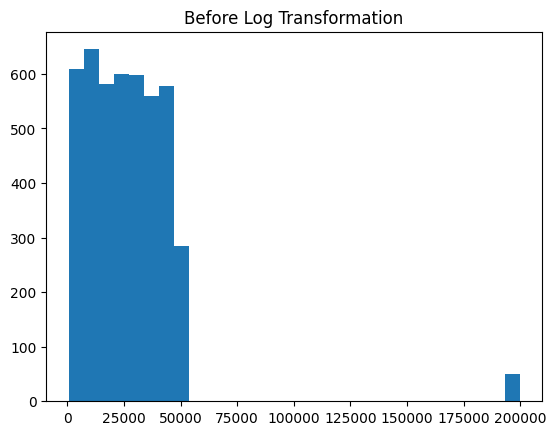

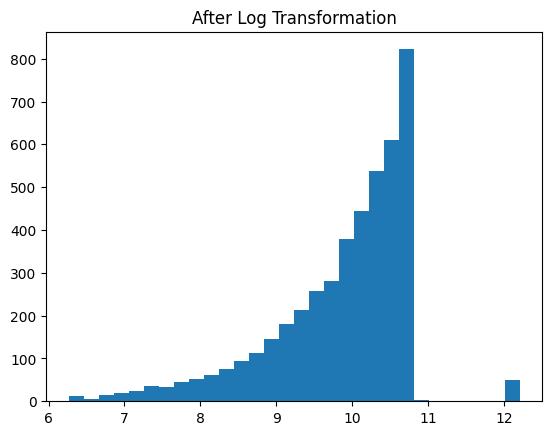

In [53]:
# Q8. Transformation

# Scenario : Treatment cost is highly skewed.

# Task:

# - Apply log transformation
# - Create a new column
# - Compare before vs after distribution

# Ans :

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/healthcare_data_cleaning_dataset.csv')

df['Log_Treatment_Cost'] = np.log(df['Treatment_Cost'])

print(df[['Treatment_Cost', 'Log_Treatment_Cost']].head())

# Before
plt.hist(df['Treatment_Cost'], bins=30)
plt.title("Before Log Transformation")
plt.show()

# After
plt.hist(df['Log_Treatment_Cost'], bins=30)
plt.title("After Log Transformation")
plt.show()

In [55]:
# Q9. Time-Based Missing Handling

# Scenario : Admission dates should follow a logical sequence.

# Task:

# - Sort data by Admission_Date
# - Apply forward fill or backward fill where appropriate
# - Justify your choice


# Ans :

df = pd.read_csv("/healthcare_data_cleaning_dataset.csv")

df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

df = df.sort_values(by='Admission_Date')

df.fillna(method='ffill', inplace=True)

print(df.head(15))

      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
2702       17230  41.0    Male  Bangalore  Hypertension               18   
2624       16450  57.0  Female    Chennai      Diabetes               15   
1791       14612  94.0    Male      Delhi  Hypertension               14   
4292       12430  25.0    Male    Chennai      Diabetes               11   
2642       19262  25.0  Female  Hyderabad        Asthma                9   
348        18716  81.0    Male      Delhi           Flu                4   
4617       10896  88.0  Female    Chennai      COVID-19                3   
866        15966  49.0  Female     Mumbai  Hypertension               10   
2838       15443   4.0  Female  Hyderabad  Hypertension               18   
1650       12356   4.0  Female      Delhi      COVID-19                4   
4837       12843  89.0  Female  Bangalore      COVID-19               14   
4563       19175  12.0  Female      Delhi           Flu                3   
329        1

/tmp/ipykernel_3695/3998130229.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


**Forward Fill is Preferred because :**

- Medical records are sequential
- Previous value is more realistic
- Maintains continuity
